<a href="https://colab.research.google.com/github/kestrel677/Supervised-Machine-learning-/blob/main/Logistic_Regression%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [71]:
df = pd.read_csv("/content/Bank_Personal_Loan_Modelling.csv")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [72]:
print(df['Personal Loan'].value_counts())

Personal Loan
0    4520
1     480
Name: count, dtype: int64


In [73]:
df.shape

(5000, 14)

In [74]:
df.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIP Code,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal Loan,int64


In [75]:
df= df.drop(columns=['ID', 'ZIP Code'])

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   Family              5000 non-null   int64  
 4   CCAvg               5000 non-null   float64
 5   Education           5000 non-null   int64  
 6   Mortgage            5000 non-null   int64  
 7   Personal Loan       5000 non-null   int64  
 8   Securities Account  5000 non-null   int64  
 9   CD Account          5000 non-null   int64  
 10  Online              5000 non-null   int64  
 11  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


In [77]:
df.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [78]:
df.isnull().sum()

,0
Age,0
Experience,0
Income,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0
Securities Account,0
CD Account,0


In [79]:
df.duplicated().sum()

np.int64(13)

In [80]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

In [81]:
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()),
                         columns=['Column', 'Outlier_Count'])

outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)

print(outlier_df)

               Column  Outlier_Count
0              Income              0
1               CCAvg              0
2            Mortgage              0
3       Personal Loan              0
4  Securities Account              0
5          CD Account              0


In [82]:
outlier_df['Percentage'] = (outlier_df['Outlier_Count'] / len(df)) * 100

print(outlier_df)

               Column  Outlier_Count  Percentage
0              Income              0         0.0
1               CCAvg              0         0.0
2            Mortgage              0         0.0
3       Personal Loan              0         0.0
4  Securities Account              0         0.0
5          CD Account              0         0.0


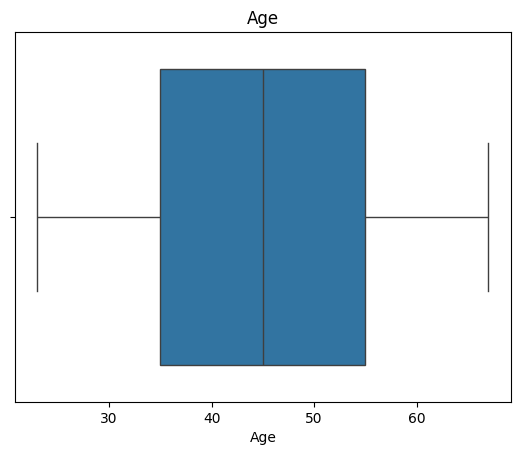

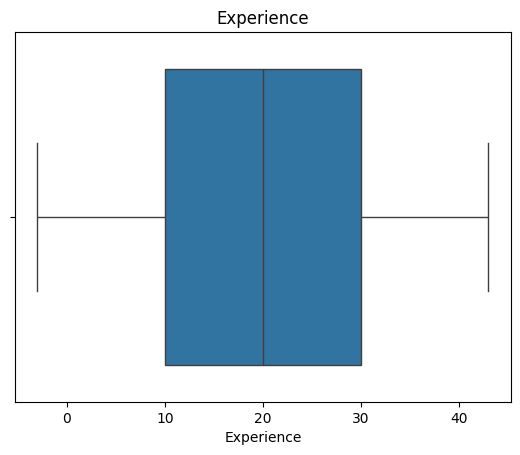

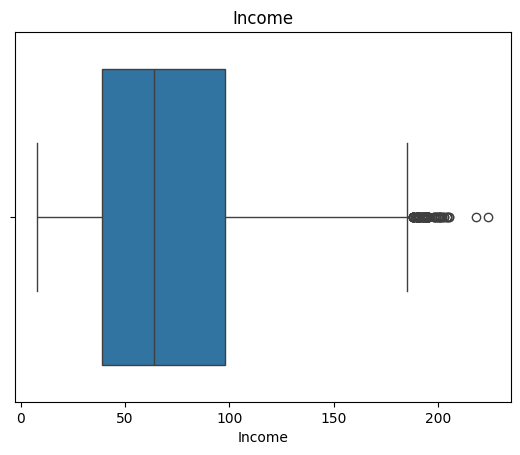

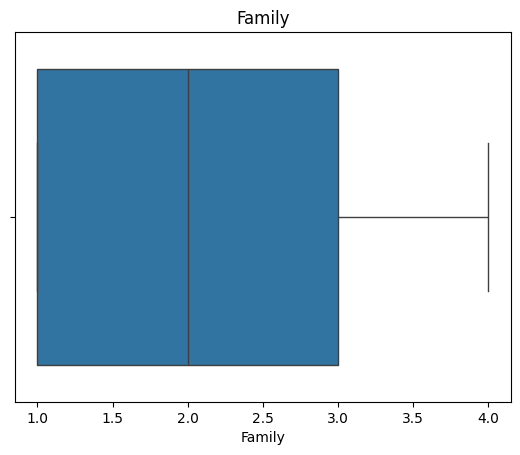

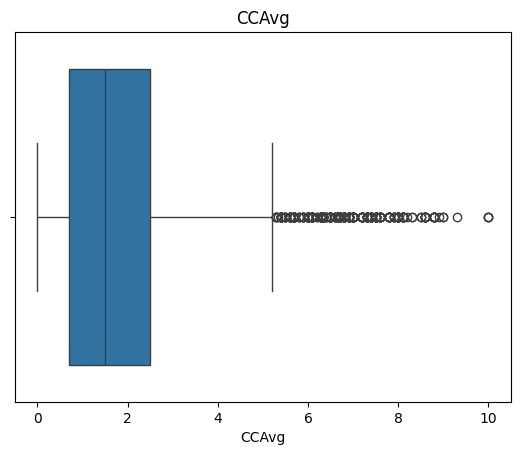

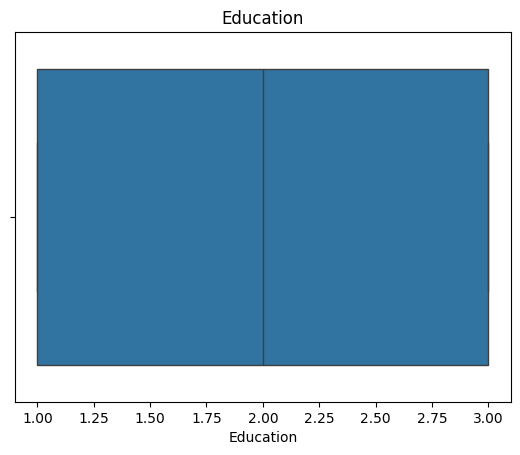

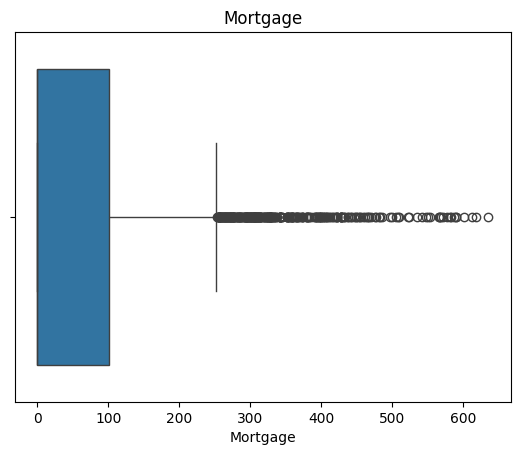

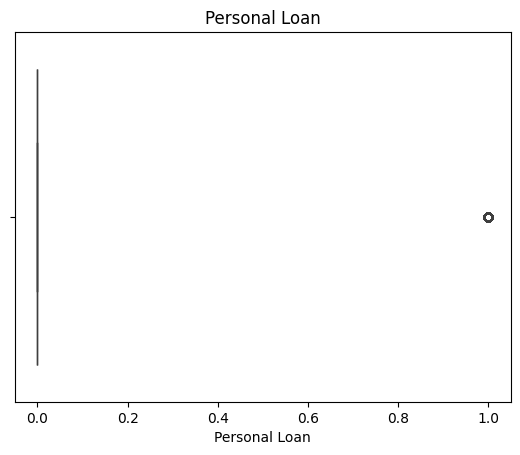

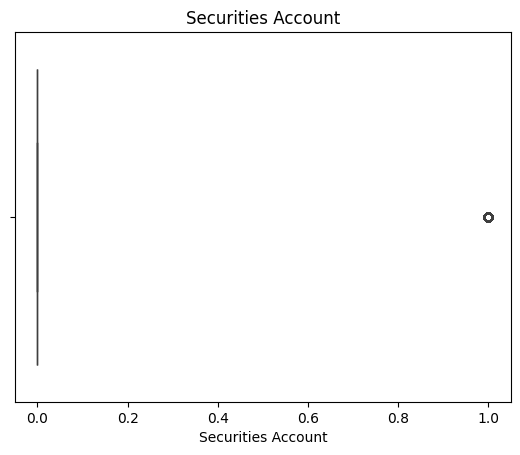

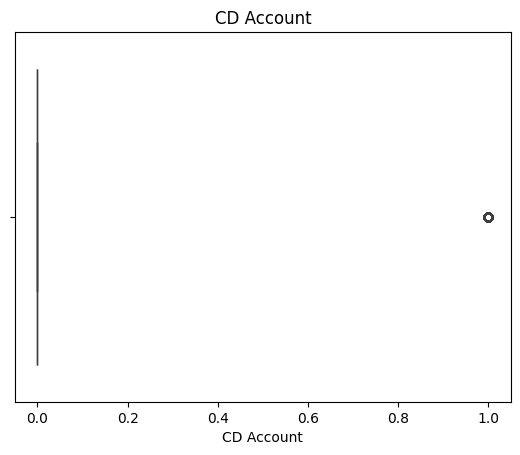

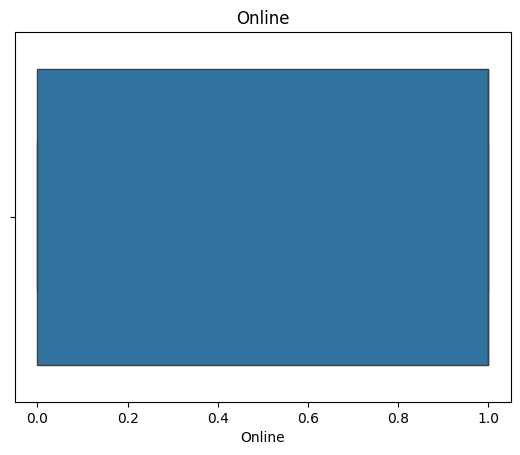

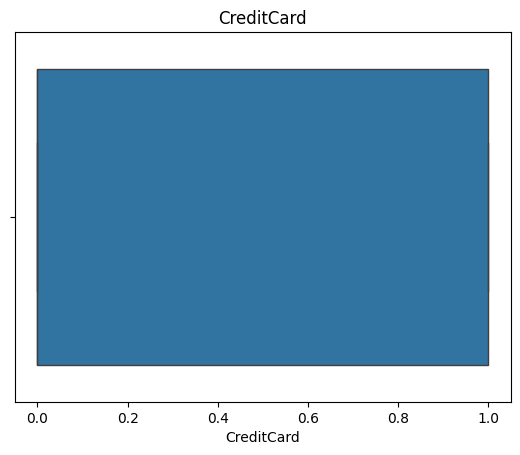

In [83]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [84]:
outlier_summary = {}

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary[col] = len(outliers)

post_capping_outlier_df = pd.DataFrame(list(outlier_summary.items()),
                                      columns=['Column', 'Outlier_Count'])

post_capping_outlier_df = post_capping_outlier_df.sort_values(by='Outlier_Count', ascending=False)

print("Outlier Summary After Capping:")
print(post_capping_outlier_df)

Outlier Summary After Capping:
               Column  Outlier_Count
4  Securities Account            522
3       Personal Loan            480
1               CCAvg            324
5          CD Account            302
2            Mortgage            291
0              Income             96


In [85]:
print(df['Personal Loan'].value_counts())

Personal Loan
0    4520
1     480
Name: count, dtype: int64


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Personal Loan', axis=1)
y = df['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [87]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000,class_weight="balanced")
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [88]:
y_pred = log_model.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.892


In [90]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       895
           1       0.49      0.92      0.64       105

    accuracy                           0.89      1000
   macro avg       0.74      0.91      0.79      1000
weighted avg       0.94      0.89      0.91      1000



In [91]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[795 100]
 [  8  97]]


In [92]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [93]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [94]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.9703112529928172


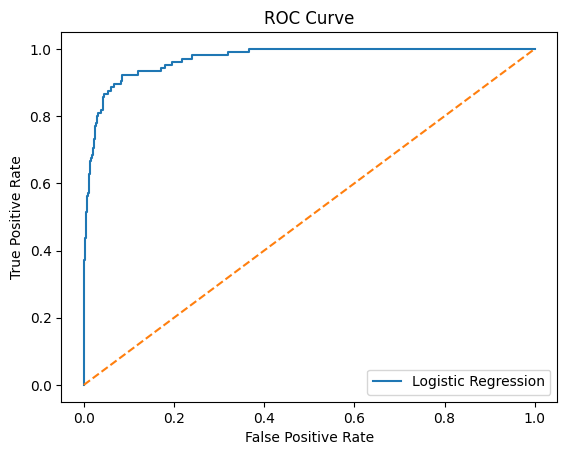

In [95]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()